# 1. Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import math
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont

import cv2
import torch
import torchvision
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import functional as F
from torchvision.transforms import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

SEED = 89
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Torch:', torch.__version__)
print('Torchvision:', torchvision.__version__)

Device: cuda
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/MOT16")

TRAIN_ROOT = DATA_ROOT / "train"
TEST_ROOT = DATA_ROOT / "test"

assert TRAIN_ROOT.exists(), f"Train path not found: {TRAIN_ROOT}"
print("Train root:", TRAIN_ROOT)
print("Test root exists:", TEST_ROOT.exists())

Train root: /content/drive/MyDrive/Colab Notebooks/MOT16/train
Test root exists: True


## 2. Helper Functions

In [ ]:
MOT_COLUMNS = [
    "frame", "track_id", "bb_left", "bb_top", "bb_width", "bb_height",
    "conf", "class_id", "visibility"
]

def xywh_to_xyxy(x, y, w, h):
    return [x, y, x + w, y + h]


def parse_gt_file(gt_file):
    """
    Parse MOT16 gt.txt file.
    Keeps only pedestrian class (class_id == 1).
    """
    df = pd.read_csv(gt_file, header=None, names=MOT_COLUMNS)
    df = df[df['class_id'] == 1].copy()
    df['sequence'] = gt_file.parent.parent.name
    df['image_id'] = df.apply(lambda row: f"{row['sequence']}/{int(row['frame']):06d}", axis=1)
    df['x1'] = df['bb_left'].astype(float)
    df['y1'] = df['bb_top'].astype(float)
    df['x2'] = (df['bb_left'] + df['bb_width']).astype(float)
    df['y2'] = (df['bb_top'] + df['bb_height']).astype(float)
    return df


def load_train_annotations(train_root):
    all_dfs = []
    for seq_dir in sorted(train_root.iterdir()):
        if not seq_dir.is_dir():
            continue
        gt_file = seq_dir / 'gt' / 'gt.txt'
        if gt_file.exists():
            seq_df = parse_gt_file(gt_file)
            all_dfs.append(seq_df)
    if not all_dfs:
        raise FileNotFoundError('No gt.txt files found under train root.')
    return pd.concat(all_dfs, ignore_index=True)

## Data Visualization (sanity check)

In [ ]:
train_df = load_train_annotations(TRAIN_ROOT)
print(train_df.head())
print('Rows:', len(train_df))
print('Sequences:', train_df['sequence'].nunique())
print('Images with labels:', train_df['image_id'].nunique())

   frame  track_id  bb_left  bb_top  bb_width  bb_height  conf  class_id  \
0      1         2     1338     418       167        379     1         1   
1      2         2     1342     417       168        380     1         1   
2      3         2     1346     417       170        380     1         1   
3      4         2     1351     417       171        381     1         1   
4      5         2     1355     417       173        381     1         1   

   visibility  sequence         image_id      x1     y1      x2     y2  
0         1.0  MOT16-02  MOT16-02/000001  1338.0  418.0  1505.0  797.0  
1         1.0  MOT16-02  MOT16-02/000002  1342.0  417.0  1510.0  797.0  
2         1.0  MOT16-02  MOT16-02/000003  1346.0  417.0  1516.0  797.0  
3         1.0  MOT16-02  MOT16-02/000004  1351.0  417.0  1522.0  798.0  
4         1.0  MOT16-02  MOT16-02/000005  1355.0  417.0  1528.0  798.0  
Rows: 110407
Sequences: 7
Images with labels: 5316


## 3. Dataset


In [ ]:
class MOTDetectionDataset(Dataset):
    def __init__(self, annotations_df, train_root, transforms=None):
        self.df = annotations_df.copy()
        self.train_root = Path(train_root)
        self.transforms = transforms
        self.image_ids = sorted(self.df['image_id'].unique().tolist())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        seq_name, frame_name = image_id.split('/')
        img_path = self.train_root / seq_name / 'img1' / f'{frame_name}.jpg'
        if not img_path.exists():
            raise FileNotFoundError(f'Image not found: {img_path}')

        records = self.df[self.df['image_id'] == image_id]
        boxes = records[['x1', 'y1', 'x2', 'y2']].values.astype(np.float32)
        labels = np.ones((len(records),), dtype=np.int64)
        track_ids = records['track_id'].values.astype(np.int64)
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = np.zeros((len(records),), dtype=np.int64)

        image = Image.open(img_path).convert('RGB')

        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx]),
            'area': torch.as_tensor(areas, dtype=torch.float32),
            'iscrowd': torch.as_tensor(iscrowd, dtype=torch.int64),
            'track_ids': torch.as_tensor(track_ids, dtype=torch.int64),
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)
        else:
            image = F.to_tensor(image)

        return image, target


class ComposeTransforms:
    def __init__(self, transforms_list):
        self.transforms_list = transforms_list

    def __call__(self, image, target):
        for t in self.transforms_list:
            image, target = t(image, target)
        return image, target


class ToTensorTransform:
    def __call__(self, image, target):
        return F.to_tensor(image), target


class RandomHorizontalFlipTransform:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, target):
        if random.random() < self.p:
            width = image.shape[-1]
            image = F.hflip(image)

            boxes = target['boxes'].clone()
            boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
            target['boxes'] = boxes

        return image, target


class ResizeTransform:
    def __init__(self, size=(384, 640)):   # (H, W)
        self.size = size

    def __call__(self, image, target):
        old_w, old_h = image.size
        new_h, new_w = self.size

        image = F.resize(image, self.size)

        boxes = target["boxes"].clone()
        boxes[:, [0, 2]] = boxes[:, [0, 2]] * (new_w / old_w)
        boxes[:, [1, 3]] = boxes[:, [1, 3]] * (new_h / old_h)
        target["boxes"] = boxes

        return image, target


def get_transforms(train=True):
    t = [ResizeTransform((384, 640)), ToTensorTransform()]
    if train:
        t.append(RandomHorizontalFlipTransform(p=0.5))
    return ComposeTransforms(t)


def collate_fn(batch):
    return tuple(zip(*batch))

## 3(b)

In [ ]:
from torch.utils.data import Subset

full_dataset = MOTDetectionDataset(train_df, TRAIN_ROOT, transforms=get_transforms(train=True))

val_ratio = 0.2
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)


# small_train_dataset = Subset(train_dataset, range(min(50, len(train_dataset))))
# small_val_dataset = Subset(val_dataset, range(min(20, len(val_dataset))))

val_dataset.dataset.transforms = get_transforms(train=False)
# small_val_dataset.dataset.transforms = get_transforms(train=False)

BATCH_SIZE = 2
NUM_WORKERS = 4

train_loader = DataLoader(
    # small_train_dataset,
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    # small_val_dataset,
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

# batch_size currently = 2
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 2127
Val batches: 532


## 4. Visualize a Training Sample

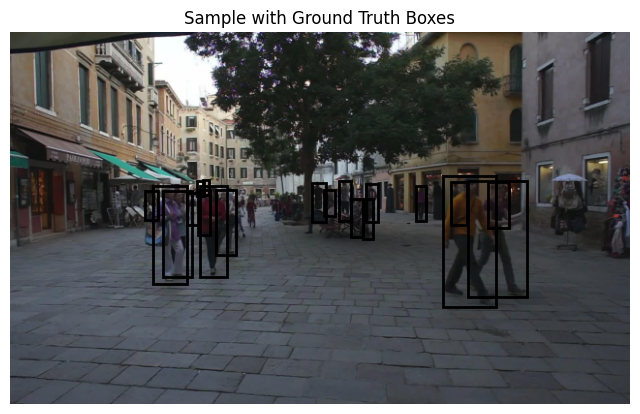

In [ ]:
def show_sample(dataset, index=None):
  if index is None:
    index = random.randint(0, len(dataset) - 1)

  img, target = dataset[index]
  img_np = img.permute(1, 2, 0).cpu().numpy()
  plt.figure(figsize=(8, 6))
  plt.imshow(img_np)
  ax = plt.gca()
  for box in target['boxes']:
      x1, y1, x2, y2 = box.tolist()
      rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
      ax.add_patch(rect)
  plt.title("Sample with Ground Truth Boxes")
  plt.axis("off")
  plt.show()

show_sample(full_dataset, 0)

## 5. Build the Faster R-CNN Model

Using a pretrained `fasterrcnn_resnet50_fpn` model and replace the prediction head for 2 classes:
- background
- pedestrian

In [ ]:
def get_model(num_classes, freeze_backbone=False):
    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    # model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=weights,
    min_size=384,
    max_size=640
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    if freeze_backbone:
        for p in model.backbone.parameters():
            p.requires_grad = False

    return model

model = get_model(num_classes=2, freeze_backbone=False)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Model ready.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 240MB/s]


Model ready.


## 6. Train the Detector

In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, device, print_every=1000):
    model.train()
    running_loss = 0.0

    for step, (images, targets) in enumerate(tqdm(loader, desc="Training Batches", leave=False), 1):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items() if k != 'track_ids'} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    return running_loss / max(len(loader), 1)


def compute_val_loss(model, loader, device, print_every=250, max_batches=None):
    model.train()
    running_loss = 0.0
    count = 0

    with torch.no_grad():
        for step, (images, targets) in enumerate(tqdm(loader, desc="Validation Batches", leave=False), 1):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items() if k != 'track_ids'} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            running_loss += losses.item()
            count += 1

            if max_batches is not None and step >= max_batches:
                break

    return running_loss / max(count, 1)


## 6(b)

In [ ]:
def plot_history(history):
  plt.figure(figsize=(7, 4))
  plt.plot(history['train_loss'], label='train_loss')
  plt.plot(history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Curves')
  plt.legend()
  plt.show()

In [ ]:
EPOCHS = 6
SAVE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/MOT16-model')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = SAVE_DIR / 'fasterrcnn_mot16_best.pth'

Loading checkpoint from /content/drive/MyDrive/Colab Notebooks/MOT16-model/fasterrcnn_mot16_best.pth


Training Epochs:   0%|          | 0/6 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/2127 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/532 [00:00<?, ?it/s]

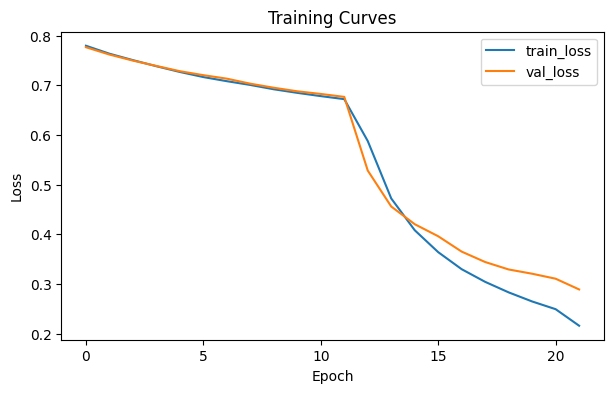

New best model saved with val_loss: 0.2889
Epoch 1/6 | train_loss=0.2159 | val_loss=0.2889 | time=218.5s


Training Batches:   0%|          | 0/2127 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/532 [00:00<?, ?it/s]

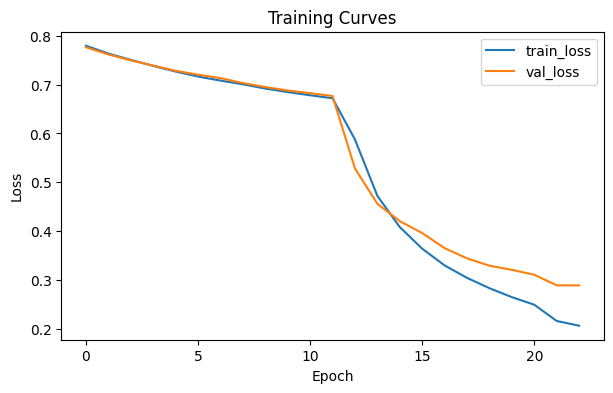

New best model saved with val_loss: 0.2888
Epoch 2/6 | train_loss=0.2062 | val_loss=0.2888 | time=182.2s


Training Batches:   0%|          | 0/2127 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a5340424360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():Exception ignored in: 
  <function _MultiProcessingDataLoaderIter.__del__ at 0x7a5340424360> 
 Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():
  ^ ^ ^ ^ ^ ^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^ 
   File "/usr/lib/

Validation Batches:   0%|          | 0/532 [00:00<?, ?it/s]

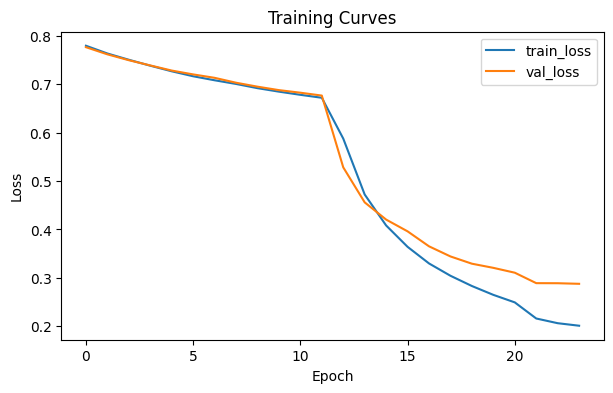

New best model saved with val_loss: 0.2876
Epoch 3/6 | train_loss=0.2010 | val_loss=0.2876 | time=182.9s


Training Batches:   0%|          | 0/2127 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a5340424360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

KeyboardInterrupt: 

  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 219, in _finalize_join
    thread.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


In [ ]:
from tqdm.auto import tqdm
import time
import os

# Load checkpoint if exists
if BEST_MODEL_PATH.exists():
    print(f"Loading checkpoint from {BEST_MODEL_PATH}")
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
else:
    print("No checkpoint found. Starting from scratch.")

# history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
optimizer = torch.optim.AdamW(params, lr=1e-6, weight_decay=1e-5)

PATIENCE = 3
epochs_without_improvement = 0

for epoch in tqdm(range(EPOCHS), desc="Training Epochs"):
    start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = compute_val_loss(model, val_loader, device)
    lr_scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    plot_history(history)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved with val_loss: {best_val:.4f}")
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"No improvement in val_loss for {epochs_without_improvement} epoch(s).")
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

    elapsed = time.time() - start
    print(f'Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | time={elapsed:.1f}s')

print('Best model saved to:', BEST_MODEL_PATH)


## 6(c)

NameError: name 'plot_history' is not defined

In [ ]:
history = {'train_loss': [0.7794970206856784,
 0.7634445218046226,
 0.7505097325329048,
 0.738223953388866,
 0.7266700769261009,
 0.7163961923733304,
 0.7081088705989302,
 0.7005041614139814,
 0.6918110666655575,
 0.6846044279764558,
 0.6780534732577158,
 0.6719695126500329], 'val_loss': [0.7764739308478241,
 0.7617041702781405,
 0.7495593567539874,
 0.7387726313637611,
 0.7281805949663758,
 0.7202279056821551,
 0.7131697967424429,
 0.7030573752253575,
 0.6948934839408201,
 0.6877477781889134,
 0.6824276758764023,
 0.6764951739880375]}

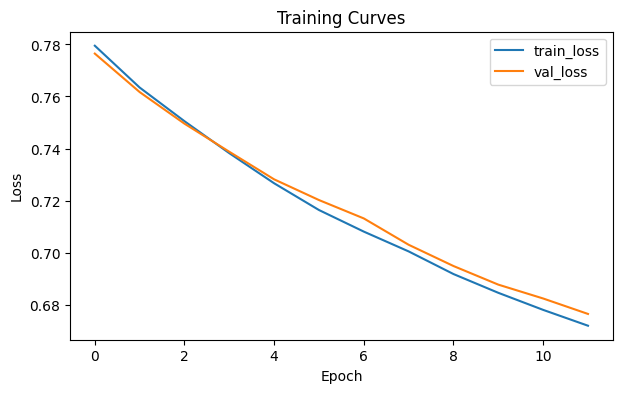

In [ ]:
plot_history(history)

## 7. Load Best Weights for Inference

In [ ]:
inference_model = get_model(num_classes=2, freeze_backbone=False)
inference_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
inference_model.to(device)
inference_model.eval()
print('Loaded best model for inference.')

Loaded best model for inference.


## 8. Detection on a Single Image

In [ ]:
@torch.no_grad()
def predict_image(model, image_path, device, score_threshold=0.7):
    image = Image.open(image_path).convert('RGB')
    tensor = F.to_tensor(image).to(device)

    output = model([tensor])[0]

    boxes = output['boxes'].detach().cpu().numpy()
    scores = output['scores'].detach().cpu().numpy()
    labels = output['labels'].detach().cpu().numpy()

    keep = scores >= score_threshold
    return image, boxes[keep], scores[keep], labels[keep]


def plot_predictions(image, boxes, scores=None):
    img_np = np.array(image)
    plt.figure(figsize=(10, 7))
    plt.imshow(img_np)
    ax = plt.gca()

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
        ax.add_patch(rect)
        if scores is not None:
            ax.text(x1, y1, f'{scores[i]:.2f}', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    plt.axis('off')
    plt.title('Predicted Detections')
    plt.show()

## 8(b)

Detections: 17


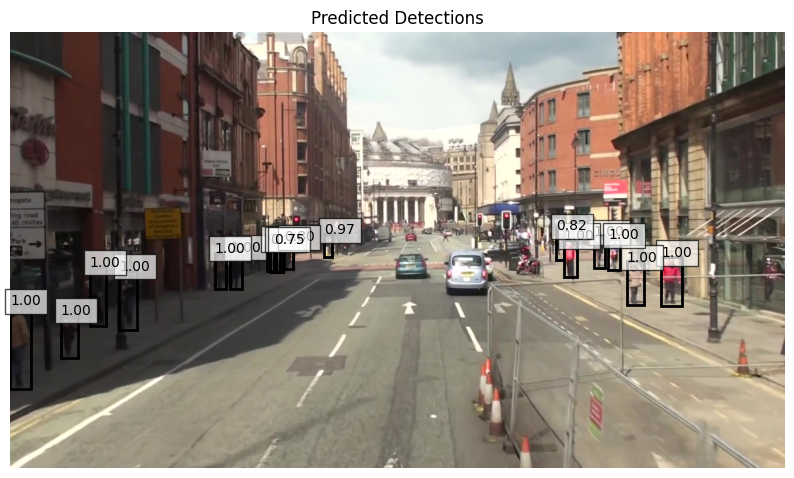

In [ ]:
# sample_seq = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])[0]
sample_seq = random.choice([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
sample_img = TRAIN_ROOT / sample_seq / 'img1' / '000001.jpg'

image, boxes, scores, labels = predict_image(inference_model, sample_img, device, score_threshold=0.7)
print('Detections:', len(boxes))
plot_predictions(image, boxes, scores)

## 9. Simple IoU Tracker

This is a lightweight tracker that assigns a persistent ID to detections across frames using:
- IoU overlap
- track age / max missed frames

In [ ]:
def compute_iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])
    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0
    return inter_area / union


class SimpleTrack:
    def __init__(self, track_id, box):
        self.track_id = track_id
        self.box = np.array(box, dtype=np.float32)
        self.missed = 0


class IoUTracker:
    def __init__(self, iou_threshold=0.3, max_missed=8):
        self.iou_threshold = iou_threshold
        self.max_missed = max_missed
        self.tracks = []
        self.next_id = 1

    def update(self, detections):
        detections = [np.array(det, dtype=np.float32) for det in detections]

        if len(self.tracks) == 0:
            self.tracks = [SimpleTrack(self.next_id + i, det) for i, det in enumerate(detections)]
            self.next_id += len(detections)
            return [(trk.track_id, trk.box.copy()) for trk in self.tracks]

        matched_det_indices = set()

        # Greedy matching by best IoU
        for track in self.tracks:
            best_iou = 0.0
            best_det_idx = -1
            for det_idx, det in enumerate(detections):
                if det_idx in matched_det_indices:
                    continue
                iou = compute_iou(track.box, det)
                if iou > best_iou:
                    best_iou = iou
                    best_det_idx = det_idx

            if best_det_idx >= 0 and best_iou >= self.iou_threshold:
                track.box = detections[best_det_idx]
                track.missed = 0
                matched_det_indices.add(best_det_idx)
            else:
                track.missed += 1

        # Remove dead tracks
        self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]

        # Add new tracks for unmatched detections
        for det_idx, det in enumerate(detections):
            if det_idx not in matched_det_indices:
                self.tracks.append(SimpleTrack(self.next_id, det))
                self.next_id += 1

        return [(trk.track_id, trk.box.copy()) for trk in self.tracks if trk.missed == 0]

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os

class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=751):
        super(SiameseNetwork, self).__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        self.fc = nn.Sequential(
            nn.Linear(resnet.fc.in_features, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward_once(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        emb = self.fc(x)
        emb_norm = nn.functional.normalize(emb, p=2, dim=1)
        return emb_norm

    def forward(self, input1):
        return self.forward_once(input1)

# 2. RE-ID TRACKER
class ReIDTrack:
    def __init__(self, track_id, box, embedding):
        self.track_id = track_id
        self.box = np.array(box, dtype=np.float32)
        self.embedding = embedding
        self.missed = 0

class ReIDTracker:
    def __init__(self, reid_model, device, distance_threshold=1.0, max_missed=8):
        self.reid_model = reid_model
        self.device = device
        self.distance_threshold = distance_threshold
        self.max_missed = max_missed
        self.tracks = []
        self.next_id = 1

        self.transform = transforms.Compose([
            transforms.Resize((256, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def get_embedding(self, image_np, box):
        x1, y1, x2, y2 = map(int, box)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(image_np.shape[1], x2), min(image_np.shape[0], y2)

        if x2 <= x1 or y2 <= y1:
            return np.zeros(128)

        crop = image_np[y1:y2, x1:x2]
        img = Image.fromarray(crop)
        img_tensor = self.transform(img).unsqueeze(0).to(self.device)

        with torch.no_grad():
            emb = self.reid_model(img_tensor)
        return emb.cpu().numpy().flatten()

    def update(self, image_np, detections):
        detections = [np.array(det, dtype=np.float32) for det in detections]
        embeddings = [self.get_embedding(image_np, det) for det in detections]

        if len(self.tracks) == 0:
            self.tracks = [ReIDTrack(self.next_id + i, det, emb) for i, (det, emb) in enumerate(zip(detections, embeddings))]
            self.next_id += len(detections)
            return [(trk.track_id, trk.box.copy()) for trk in self.tracks]

        matched_det_indices = set()

        for track in self.tracks:
            min_dist = float('inf')
            best_det_idx = -1
            for det_idx, emb in enumerate(embeddings):
                if det_idx in matched_det_indices:
                    continue
                dist = np.linalg.norm(track.embedding - emb)
                if dist < min_dist:
                    min_dist = dist
                    best_det_idx = det_idx

            if best_det_idx >= 0 and min_dist < self.distance_threshold:
                track.box = detections[best_det_idx]
                # EMA update
                track.embedding = 0.9 * track.embedding + 0.1 * embeddings[best_det_idx]
                track.missed = 0
                matched_det_indices.add(best_det_idx)
            else:
                track.missed += 1

        self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]

        for det_idx, (det, emb) in enumerate(zip(detections, embeddings)):
            if det_idx not in matched_det_indices:
                self.tracks.append(ReIDTrack(self.next_id, det, emb))
                self.next_id += 1

        return [(trk.track_id, trk.box.copy()) for trk in self.tracks if trk.missed == 0]

# Initialize the ReID model
reid_model = SiameseNetwork(embedding_dim=128, num_classes=751).to(device)
checkpoint_path = '/content/drive/MyDrive/ReID_Checkpoints/reid_resnet50_checkpoint.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    reid_model.load_state_dict(checkpoint['model_state_dict'])
    print("Đã tải trọng số ReID thành công!")
else:
    print(f"CẢNH BÁO: Không tìm thấy checkpoint ReID tại {checkpoint_path}. Tracker sẽ dùng trọng số khởi tạo ngẫu nhiên/ImageNet.")
reid_model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]


CẢNH BÁO: Không tìm thấy checkpoint ReID tại /content/drive/MyDrive/ReID_Checkpoints/reid_resnet50_checkpoint.pth. Tracker sẽ dùng trọng số khởi tạo ngẫu nhiên/ImageNet.


SiameseNetwork(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Con

## 10. Run Tracking on a Full Sequence and Export Video (In Progress)

In [ ]:
@torch.no_grad()
def get_detections_for_frame(model, image_path, device, score_threshold=0.7):
    image = Image.open(image_path).convert('RGB')
    tensor = F.to_tensor(image).to(device)
    output = model([tensor])[0]

    boxes = output['boxes'].detach().cpu().numpy()
    scores = output['scores'].detach().cpu().numpy()

    keep = scores >= score_threshold
    return np.array(image), boxes[keep], scores[keep]


def draw_tracks(image_np, tracked_objects, scores=None):
    frame = image_np.copy()
    for idx, (track_id, box) in enumerate(tracked_objects):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f'ID {track_id}'
        cv2.putText(frame, label, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return frame


def export_tracked_video(
    model,
    seq_dir,
    output_path,
    device,
    score_threshold=0.7,
    iou_threshold=0.3,
    max_missed=8,
    max_frames=None,
    fps=10,
):
    seq_dir = Path(seq_dir)
    img_dir = seq_dir / 'img1'
    frame_paths = sorted(img_dir.glob('*.jpg'))
    if max_frames is not None:
        frame_paths = frame_paths[:max_frames]

    if len(frame_paths) == 0:
        raise FileNotFoundError(f'No frames found in: {img_dir}')

    sample = cv2.imread(str(frame_paths[0]))
    height, width = sample.shape[:2]

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    tracker = IoUTracker(iou_threshold=iou_threshold, max_missed=max_missed)

    for i, frame_path in enumerate(frame_paths):
        image_np, boxes, scores = get_detections_for_frame(model, frame_path, device, score_threshold)
        tracked_objects = tracker.update(boxes)
        vis_frame = draw_tracks(image_np, tracked_objects)
        vis_frame_bgr = cv2.cvtColor(vis_frame, cv2.COLOR_RGB2BGR)
        writer.write(vis_frame_bgr)

        if (i + 1) % 50 == 0 or (i + 1) == len(frame_paths):
            print(f'Processed {i+1}/{len(frame_paths)} frames')

    writer.release()
    print('Saved tracked video to:', output_path)

In [ ]:
import cv2
from pathlib import Path
import numpy as np
from PIL import Image
import torchvision.transforms.functional as F
import torch

@torch.no_grad()
def get_detections_for_frame(model, image_path, device, score_threshold=0.7):
    image = Image.open(image_path).convert('RGB')
    tensor = F.to_tensor(image).to(device)
    output = model([tensor])[0]

    boxes = output['boxes'].detach().cpu().numpy()
    scores = output['scores'].detach().cpu().numpy()

    keep = scores >= score_threshold
    return np.array(image), boxes[keep], scores[keep]

def draw_tracks(image_np, tracked_objects, scores=None):
    frame = image_np.copy()
    for idx, (track_id, box) in enumerate(tracked_objects):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f'ID {track_id}'
        cv2.putText(frame, label, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return frame

def export_tracked_video_reid(
    detection_model,
    reid_model,
    seq_dir,
    output_path,
    device,
    score_threshold=0.7,
    distance_threshold=1.0,
    max_missed=8,
    max_frames=None,
    fps=10,
):
    seq_dir = Path(seq_dir)
    img_dir = seq_dir / 'img1'
    frame_paths = sorted(img_dir.glob('*.jpg'))
    if max_frames is not None:
        frame_paths = frame_paths[:max_frames]

    if len(frame_paths) == 0:
        raise FileNotFoundError(f'No frames found in: {img_dir}')

    sample = cv2.imread(str(frame_paths[0]))
    height, width = sample.shape[:2]

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    tracker = ReIDTracker(reid_model=reid_model, device=device, distance_threshold=distance_threshold, max_missed=max_missed)

    for i, frame_path in enumerate(frame_paths):
        image_np, boxes, scores = get_detections_for_frame(detection_model, frame_path, device, score_threshold)

        # Tracker uses image crops to extract embeddings
        tracked_objects = tracker.update(image_np, boxes)

        vis_frame = draw_tracks(image_np, tracked_objects)
        vis_frame_bgr = cv2.cvtColor(vis_frame, cv2.COLOR_RGB2BGR)
        writer.write(vis_frame_bgr)

        if (i + 1) % 50 == 0 or (i + 1) == len(frame_paths):
            print(f'Processed {i+1}/{len(frame_paths)} frames')

    writer.release()
    print('Saved ReID tracked video to:', output_path)

In [ ]:
# Run the ReID Tracker on a sample sequence
sequence_name = sample_seq
sequence_dir = TRAIN_ROOT / sequence_name
output_video_reid = SAVE_DIR / f'{sequence_name}_reid_tracked.mp4'

export_tracked_video_reid(
    detection_model=inference_model,
    reid_model=reid_model,
    seq_dir=sequence_dir,
    output_path=output_video_reid,
    device=device,
    score_threshold=0.7,
    distance_threshold=1.0,
    max_missed=8,
    max_frames=200,
    fps=10,
)

Processed 50/200 frames
Processed 100/200 frames
Processed 150/200 frames
Processed 200/200 frames
Saved ReID tracked video to: /content/drive/MyDrive/Colab Notebooks/MOT16-model/MOT16-13_reid_tracked.mp4


## 10(b)

In [ ]:
# sequence_name = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])[0]
# sequence_name = random.choice([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
sequence_name = sample_seq
sequence_dir = TRAIN_ROOT / sequence_name
output_video = SAVE_DIR / f'{sequence_name}_tracked.mp4'

export_tracked_video(
    inference_model,
    sequence_dir,
    output_video,
    device=device,
    score_threshold=0.7,
    iou_threshold=0.3,
    max_missed=8,
    max_frames=200,
    fps=10,
)

Processed 50/200 frames
Processed 100/200 frames
Processed 150/200 frames
Processed 200/200 frames
Saved tracked video to: /content/drive/MyDrive/Colab Notebooks/MOT16-model/MOT16-04_tracked.mp4
